<a href="https://colab.research.google.com/github/hiranshree/Repo/blob/main/preprocessing_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import os

# ==========================================
# 1. FORMATTING
# ==========================================
def preprocess_formatting(df):
    """Initial cleanup: standardize timestamps and ensure numeric data."""
    if 'Timestamp' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Timestamp'})
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df = df.dropna(subset=['Timestamp']).drop_duplicates(subset=['Timestamp'])
    df = df.set_index('Timestamp').sort_index()
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df*0.001  # Convert to kWh
    return df.round(4)

# ==========================================
# 2. INCLUSION LOGIC (With Analysis Report)
# ==========================================
def identify_qualified_buildings(df, threshold=10.0):
    """
    Identifies buildings with a 180-day high-quality window and generates a full report.
    """
    analysis_report = []
    accepted_cols = []

    # 180 days * 24 hours * 12 intervals (5-min) = 51840
    # Note: Using 17280 for 15-min or 51840 for 5-min based on your filename
    window_intervals = 17280

    for col in df.columns:
        series = df[col]

        # Identify bad data categories
        is_null = series.isna()
        is_zero = (series == 0)
        m, s = series.mean(), series.std()
        is_outlier = (series > m + 3*s) | (series < m - 3*s)

        # Bad data mask for rolling quality check
        bad_mask = is_null | is_zero | is_outlier
        bad_rate_rolling = bad_mask.rolling(window=window_intervals, min_periods=window_intervals).mean() * 100

        # Scan for best quality 6-month window
        best_window_error = round(bad_rate_rolling.min(), 2) if not bad_rate_rolling.dropna().empty else 100.0

        if (bad_rate_rolling <= threshold).any():
            accepted_cols.append(col)
            status = "ACCEPTED"
        else:
            status = "REJECTED"

        # Global stats for the report
        analysis_report.append({
            'Building': col,
            'Missing_%': round((is_null.sum()/len(df))*100, 2),
            'Zeros_%': round((is_zero.sum()/len(df))*100, 2),
            'Outliers_%': round((is_outlier.sum()/len(df))*100, 2),
            'Best_6Mo_Window_Bad_%': best_window_error,
            'Status': status
        })

    return df[accepted_cols], pd.DataFrame(analysis_report)

# ==========================================
# 3. CONSOLIDATED MERGING & SAVING
# ==========================================
def finalize_and_save(df_filtered, base_path='processed'):
    """Resamples and saves the consolidated data."""
    resolutions = {'15min': '15T', '30min': '30T', 'hourly': 'H'}
    df_cleaned = df_filtered.replace(0, np.nan)

    for label, res_code in resolutions.items():
        # Aggregating using sum with min_count=1 to keep NaNs accurate
        resampled = df_cleaned.resample(res_code).sum(min_count=1).round(4)
        resampled = resampled.dropna(how='all')
        resampled.index.name = 'Timestamp'

        folder = os.path.join(base_path, label)
        os.makedirs(folder, exist_ok=True)

        csv_path = os.path.join(folder, f"Electricity-{label}.csv")
        parquet_path = os.path.join(folder, f"Electricity-{label}.parquet")
        resampled.to_csv(csv_path, index=True)
        resampled.to_parquet(parquet_path, index=True)
        print(f"Saved {label} consolidated file.")

# ==========================================
# MAIN PIPELINE
# ==========================================
def run_pipeline():
    # Load raw EnerNOC data
    if not os.path.exists('/content/enernoc_5min.csv'):
        print("Error: Input file not found.")
        return

    df_raw = pd.read_csv('/content/enernoc_5min.csv')
    df_fmt = preprocess_formatting(df_raw)

    # Step 2: Quality Filtering & Report Generation
    df_qualified, report = identify_qualified_buildings(df_fmt, threshold=10.0)

    # Save the detailed analysis report
    report.to_csv('data_quality_analysis.csv', index=False)
    print("Saved data_quality_analysis.csv")

    if not df_qualified.empty:
        # Step 3: Resample and Save
        finalize_and_save(df_qualified)
        print("\nProcessing complete. Original timelines preserved for qualified buildings.")
    else:
        print("\nNo buildings met the criteria.")

if __name__ == "__main__":
    run_pipeline()

Saved data_quality_analysis.csv


/tmp/ipykernel_1172/848438425.py:77: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled = df_cleaned.resample(res_code).sum(min_count=1).round(4)


Saved 15min consolidated file.


/tmp/ipykernel_1172/848438425.py:77: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled = df_cleaned.resample(res_code).sum(min_count=1).round(4)


Saved 30min consolidated file.


/tmp/ipykernel_1172/848438425.py:77: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  resampled = df_cleaned.resample(res_code).sum(min_count=1).round(4)


Saved hourly consolidated file.

Processing complete. Original timelines preserved for qualified buildings.


In [ ]:
import pandas as pd
import numpy as np
import os

# ==========================================
# 1. FORMATTING
# ==========================================
def preprocess_formatting(df):
    """Initial cleanup: standardize timestamps and ensure numeric data."""
    if 'Timestamp' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Timestamp'})
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df = df.dropna(subset=['Timestamp']).drop_duplicates(subset=['Timestamp'])
    df = df.set_index('Timestamp').sort_index()
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df*0.001  # Convert to kWh
    return df.round(4)

# ==========================================
# 2. INCLUSION LOGIC (With Analysis Report)
# ==========================================
def identify_qualified_buildings(df, threshold=10.0):
    """
    Identifies buildings with a 180-day high-quality window and generates a full report.
    """
    analysis_report = []
    accepted_cols = []

    # 180 days * 24 hours * 12 intervals (5-min) = 51840
    # Note: Using 17280 for 15-min or 51840 for 5-min based on your filename
    window_intervals = 90 * 24 * 12  # Adjusted to 90 days for a more realistic window size

    for col in df.columns:
        series = df[col]

        # Identify bad data categories
        is_null = series.isna()
        is_zero = (series == 0)
        m, s = series.mean(), series.std()
        is_outlier = (series > m + 3*s) | (series < m - 3*s)

        # Bad data mask for rolling quality check
        bad_mask = is_null | is_zero | is_outlier
        bad_rate_rolling = bad_mask.rolling(window=window_intervals, min_periods=window_intervals).mean() * 100

        # Scan for best quality 6-month window
        best_window_error = round(bad_rate_rolling.min(), 2) if not bad_rate_rolling.dropna().empty else 100.0

        if (bad_rate_rolling <= threshold).any():
            accepted_cols.append(col)
            status = "ACCEPTED"
        else:
            status = "REJECTED"

        # Global stats for the report
        analysis_report.append({
            'Building': col,
            'Missing_%': round((is_null.sum()/len(df))*100, 2),
            'Zeros_%': round((is_zero.sum()/len(df))*100, 2),
            'Outliers_%': round((is_outlier.sum()/len(df))*100, 2),
            'Best_6Mo_Window_Bad_%': best_window_error,
            'Status': status
        })

    return df[accepted_cols], pd.DataFrame(analysis_report)

# ==========================================
# 3. CONSOLIDATED MERGING & SAVING
# ==========================================
def finalize_and_save(df_filtered, base_path='./processed/3months'):
    """Resamples and saves the consolidated data."""
    resolutions = {'15min': '15T', '30min': '30T', 'hourly': 'H'}
    df_cleaned = df_filtered.replace(0, np.nan)

    for label, res_code in resolutions.items():
        # Aggregating using sum with min_count=1 to keep NaNs accurate
        resampled = df_cleaned.resample(res_code).sum(min_count=1).round(4)
        resampled = resampled.dropna(how='all')
        resampled.index.name = 'Timestamp'

        folder = os.path.join(base_path, label)
        os.makedirs(folder, exist_ok=True)

        csv_path = os.path.join(folder, f"Electricity-{label}.csv")
        parquet_path = os.path.join(folder, f"Electricity-{label}.parquet")
        resampled.to_csv(csv_path, index=True)
        resampled.to_parquet(parquet_path, index=True)
        print(f"Saved {label} consolidated file.")

# ==========================================
# MAIN PIPELINE
# ==========================================
def run_pipeline():
    # Load raw EnerNOC data
    if not os.path.exists('/content/enernoc_5min.csv'):
        print("Error: Input file not found.")
        return

    df_raw = pd.read_csv('/content/enernoc_5min.csv')
    df_fmt = preprocess_formatting(df_raw)

    # Step 2: Quality Filtering & Report Generation
    df_qualified, report = identify_qualified_buildings(df_fmt, threshold=10.0)

    # Save the detailed analysis report
    report.to_csv('3month_data_quality_analysis.csv', index=False)
    print("Saved 3month_data_quality_analysis.csv")

    if not df_qualified.empty:
        # Step 3: Resample and Save
        finalize_and_save(df_qualified)
        print("\nProcessing complete. Original timelines preserved for qualified buildings.")
    else:
        print("\nNo buildings met the criteria.")

if __name__ == "__main__":
    run_pipeline()

Saved 3month_data_quality_analysis.csv


/tmp/ipykernel_1172/3872549804.py:77: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled = df_cleaned.resample(res_code).sum(min_count=1).round(4)


Saved 15min consolidated file.


/tmp/ipykernel_1172/3872549804.py:77: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled = df_cleaned.resample(res_code).sum(min_count=1).round(4)


Saved 30min consolidated file.


/tmp/ipykernel_1172/3872549804.py:77: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  resampled = df_cleaned.resample(res_code).sum(min_count=1).round(4)


Saved hourly consolidated file.

Processing complete. Original timelines preserved for qualified buildings.


In [ ]:
import pandas as pd
import numpy as np
import os

# ==========================================
# 1. FORMATTING
# ==========================================
def preprocess_formatting(df):
    """Initial cleanup: standardize timestamps and ensure numeric data."""
    if 'Timestamp' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Timestamp'})
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df = df.dropna(subset=['Timestamp']).drop_duplicates(subset=['Timestamp'])
    df = df.set_index('Timestamp').sort_index()
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df*0.001  # Convert to kWh
    return df.round(4)

# ==========================================
# 2. INCLUSION LOGIC (With Analysis Report)
# ==========================================
def identify_qualified_buildings(df, threshold=10.0):
    """
    Identifies buildings with a 180-day high-quality window and generates a full report.
    """
    analysis_report = []
    accepted_cols = []

    # 180 days * 24 hours * 12 intervals (5-min) = 51840
    # Note: Using 17280 for 15-min or 51840 for 5-min based on your filename
    window_intervals = 30 * 24 * 12  # Adjusted to 30 days for a more realistic window size

    for col in df.columns:
        series = df[col]

        # Identify bad data categories
        is_null = series.isna()
        is_zero = (series == 0)
        m, s = series.mean(), series.std()
        is_outlier = (series > m + 3*s) | (series < m - 3*s)

        # Bad data mask for rolling quality check
        bad_mask = is_null | is_zero | is_outlier
        bad_rate_rolling = bad_mask.rolling(window=window_intervals, min_periods=window_intervals).mean() * 100

        # Scan for best quality 6-month window
        best_window_error = round(bad_rate_rolling.min(), 2) if not bad_rate_rolling.dropna().empty else 100.0

        if (bad_rate_rolling <= threshold).any():
            accepted_cols.append(col)
            status = "ACCEPTED"
        else:
            status = "REJECTED"

        # Global stats for the report
        analysis_report.append({
            'Building': col,
            'Missing_%': round((is_null.sum()/len(df))*100, 2),
            'Zeros_%': round((is_zero.sum()/len(df))*100, 2),
            'Outliers_%': round((is_outlier.sum()/len(df))*100, 2),
            'Best_6Mo_Window_Bad_%': best_window_error,
            'Status': status
        })

    return df[accepted_cols], pd.DataFrame(analysis_report)

# ==========================================
# 3. CONSOLIDATED MERGING & SAVING
# ==========================================
def finalize_and_save(df_filtered, base_path='./processed/1month'):
    """Resamples and saves the consolidated data."""
    resolutions = {'15min': '15T', '30min': '30T', 'hourly': 'H'}
    df_cleaned = df_filtered.replace(0, np.nan)

    for label, res_code in resolutions.items():
        # Aggregating using sum with min_count=1 to keep NaNs accurate
        resampled = df_cleaned.resample(res_code).sum(min_count=1).round(4)
        resampled = resampled.dropna(how='all')
        resampled.index.name = 'Timestamp'

        folder = os.path.join(base_path, label)
        os.makedirs(folder, exist_ok=True)

        csv_path = os.path.join(folder, f"Electricity-{label}.csv")
        parquet_path = os.path.join(folder, f"Electricity-{label}.parquet")
        resampled.to_csv(csv_path, index=True)
        resampled.to_parquet(parquet_path, index=True)
        print(f"Saved {label} consolidated file.")

# ==========================================
# MAIN PIPELINE
# ==========================================
def run_pipeline():
    # Load raw EnerNOC data
    if not os.path.exists('/content/enernoc_5min.csv'):
        print("Error: Input file not found.")
        return

    df_raw = pd.read_csv('/content/enernoc_5min.csv')
    df_fmt = preprocess_formatting(df_raw)

    # Step 2: Quality Filtering & Report Generation
    df_qualified, report = identify_qualified_buildings(df_fmt, threshold=10.0)

    # Save the detailed analysis report
    report.to_csv('1month_data_quality_analysis.csv', index=False)
    print("Saved 1month_data_quality_analysis.csv")

    if not df_qualified.empty:
        # Step 3: Resample and Save
        finalize_and_save(df_qualified)
        print("\nProcessing complete. Original timelines preserved for qualified buildings.")
    else:
        print("\nNo buildings met the criteria.")

if __name__ == "__main__":
    run_pipeline()

Saved 1month_data_quality_analysis.csv


/tmp/ipykernel_1172/2192428776.py:77: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled = df_cleaned.resample(res_code).sum(min_count=1).round(4)


Saved 15min consolidated file.


/tmp/ipykernel_1172/2192428776.py:77: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled = df_cleaned.resample(res_code).sum(min_count=1).round(4)


Saved 30min consolidated file.


/tmp/ipykernel_1172/2192428776.py:77: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  resampled = df_cleaned.resample(res_code).sum(min_count=1).round(4)


Saved hourly consolidated file.

Processing complete. Original timelines preserved for qualified buildings.


In [ ]:
df1 = pd.read_csv('/content/processed/3months/hourly/Electricity-hourly.csv')
df1.head()

,Timestamp,767,304,399,21,805,14,404,78,218,...,484,674,8,92,339,887,42,475,765,716
0,2012-01-01 00:00:00,NaN,0.1380,0.2908,0.2130,0.0315,1.5169,0.0284,0.4995,0.1009,...,0.1500,0.0154,0.2099,0.0201,0.3077,0.5710,0.5781,0.2377,0.0821,1.1121
1,2012-01-01 01:00:00,NaN,0.1502,0.3489,0.2556,0.0294,1.6412,0.0302,0.5937,0.1104,...,0.1661,0.0222,0.2519,0.0217,0.3595,0.6788,0.6872,0.2564,0.0903,1.1916
2,2012-01-01 02:00:00,NaN,0.1635,0.3267,0.2556,0.0253,1.6771,0.0257,0.5947,0.1104,...,0.1708,0.0231,0.2520,0.0222,0.3480,0.6800,0.6884,0.2755,0.0978,1.1321
3,2012-01-01 03:00:00,NaN,0.1579,0.3133,0.2556,0.0411,1.6906,0.0418,0.5927,0.1068,...,0.1590,0.0240,0.2520,0.0217,0.3338,0.6775,0.6859,0.2674,0.0912,1.1308
4,2012-01-01 04:00:00,NaN,0.1610,0.2838,0.2556,0.0249,1.7434,0.0255,0.5832,0.1056,...,0.1594,0.0231,0.2520,0.0217,0.3226,0.6670,0.6752,0.2435,0.0894,1.1285


Generating heatmap for 98 buildings...


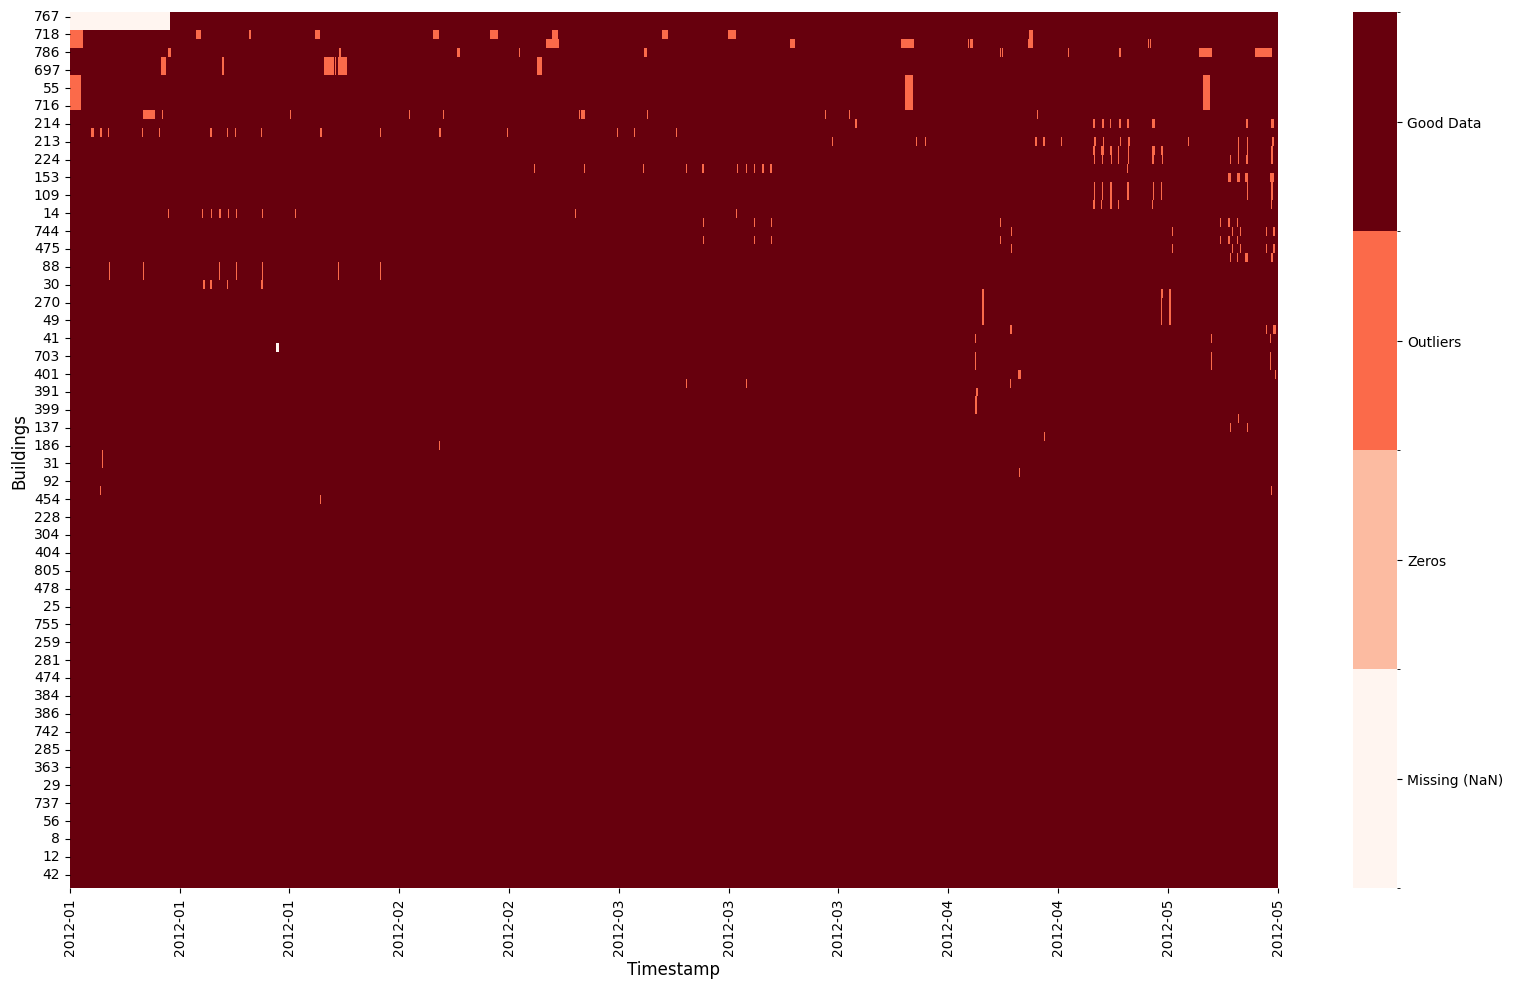

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

def plot_data_quality_heatmap(df, title=""):

    # 1. Create masks efficiently
    is_null = df.isna().values
    is_zero = (df == 0).values

    # Calculate outliers column-wise
    m = df.mean()
    s = df.std()
    is_outlier = ((df > m + 3*s) | (df < m - 3*s)).values

    # 2. Re-map numeric values (int8 saves RAM)
    # 0 = Missing, 1 = Zeros, 2 = Outliers, 3 = Good Data
    quality_grid = np.full(df.shape, 3, dtype=np.int8)
    quality_grid[is_null] = 0
    quality_grid[is_zero] = 1
    quality_grid[is_outlier] = 2

    # Create the quality DataFrame
    temp_quality_df = pd.DataFrame(quality_grid, index=df.index, columns=df.columns)

    # --- 3. ASCENDING SORT LOGIC ---
    # Count occurrences of '3' (Good Data) for each building
    good_data_counts = (temp_quality_df == 3).sum().sort_values(ascending=True)
    sorted_buildings = good_data_counts.index

    # Reorder the buildings: Least good data at the top (start of list), most at bottom
    plot_df = temp_quality_df[sorted_buildings].T

    # 4. SAFE VISUALIZATION LOGIC
    num_buildings = len(plot_df.index)
    dynamic_height = max(10, num_buildings * 0.05)
    dynamic_height = min(300, dynamic_height)

    print(f"Generating heatmap for {num_buildings} buildings...")
    plt.figure(figsize=(16, dynamic_height))

    colors = ["#fff5f0", "#fcbba1", "#fb6a4a", "#67000d"]
    cmap = mcolors.ListedColormap(colors)
    bounds = [0, 1, 2, 3, 4]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # 5. Generate Heatmap
    ax = sns.heatmap(plot_df, cmap=cmap, norm=norm,
                     rasterized=True,
                     cbar_kws={
                         'label': '',
                         'ticks': [0.5, 1.5, 2.5, 3.5]
                     })

    # 6. Customize Legend
    colorbar = ax.collections[0].colorbar
    colorbar.set_ticklabels(['Missing (NaN)', 'Zeros', 'Outliers', 'Good Data'])

    # 7. Formatting
    plt.title("", fontsize=16, pad=20)
    plt.xlabel("Timestamp", fontsize=12)
    plt.ylabel("Buildings", fontsize=12)

    xticks = np.linspace(0, len(df.index) - 1, 12).astype(int)
    ax.set_xticks(xticks)
    ax.set_xticklabels(df.index[xticks].strftime('%Y-%m'), rotation=90)

    plt.tight_layout()

    output_path = 'Enernoc_data_quality_heatmap.png'
    plt.savefig(output_path, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()

if __name__ == '__main__':
    df_raw = pd.read_csv('/content/processed/3months/hourly/Electricity-hourly.csv', index_col='Timestamp', parse_dates=True)
    plot_data_quality_heatmap(df_raw)